# Multivariate DI illustration on a synthetic 3D population

This notebook gives a compact visual explanation of the multivariate extension of the Density Index (DI). It creates one overlapping three-dimensional population and contrasts three samples of size three: locally clustered (underspread), close to the reference medoids (near-zero DI), and overspread. For every case it constructs balanced clusters, identifies population medoids, and calculates sample-level n-medoids DI.

The final figure follows the paper's notation: red bullets are observed sampled units (initial centers) and black crosses are IPnM medoids (reference units). Color identifies the balanced clusters and dashed segments show the optimal one-to-one medoid-to-sample assignment used by DI.

In [1]:
from pathlib import Path
from types import SimpleNamespace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist

from graphical_sampling.clustering import FIPBalancedNMeans
from graphical_sampling.index import DensityDisparity

plt.style.use('seaborn-v0_8-whitegrid')
rng = np.random.default_rng(20260903)

## 1. Generate an overlapping 3D population

The three dimensions can represent three standardized coordinates or three continuous auxiliary variables. The component distributions overlap deliberately, so the balanced clusters are not isolated clouds. Equal first-order inclusion probabilities keep the illustration transparent. The lightweight population container is needed because the repository's standard `Population` validator currently restricts coordinates to two columns; the clustering and DI calculations themselves operate on an arbitrary number of dimensions.

In [2]:
N = 600
n = 3

# Strongly overlapping components create one continuous-looking population.
component_centers = np.array([
    [-0.45, -0.15, -0.20],
    [ 0.30,  0.35,  0.20],
    [ 0.35, -0.35,  0.15],
])
component_sizes = [200, 200, 200]
coords_raw = np.vstack([
    rng.normal(loc=center, scale=[0.62, 0.58, 0.60], size=(size, 3))
    for center, size in zip(component_centers, component_sizes)
])

# Match the package convention: translate to zero and apply one common scale,
# preserving relative geometry across dimensions.
coords = coords_raw - coords_raw.min(axis=0)
coords /= np.ptp(coords, axis=0).max()
pik = np.full(N, n / N)
population = SimpleNamespace(
    coords=np.ascontiguousarray(coords), inclusions=pik,
    indices=np.arange(N), ids=np.arange(1, N + 1),
    variable=np.zeros(N), N=N, n=n,
)

print(f'Population size N={N}; sample size n={n}')

Population size N=600; sample size n=3


## 2. Construct and verify three sample configurations

The calculation follows `DensityDisparity._process_one_sample`. The locally clustered sample is selected from the 25 units nearest the population center, maximizing separation within that small central neighborhood so its symbols remain distinguishable. The overspread sample uses a population-wide maximum-distance pair and a third unit maximizing its minimum distance from that pair. For the representative case, the medoid update is first iterated to a fixed point and each medoid is then replaced by a nearby—but distinct—population unit. Its DI is therefore close to, but not exactly, zero. The resulting signs and magnitudes are checked explicitly.

In [3]:
scorer = DensityDisparity(population=population, representative='nmedoids', n_jobs=1)

class SampleInitializedOT(FIPBalancedNMeans):
    def _get_labels_centroids(self, x, p, init_centroids=None):
        supplied = np.asarray(init_centroids, dtype=float)
        return self._get_labels_centroids_ot_kmeans(x, p, supplied.copy())

def calculate_case(sample_indices):
    sample_indices = np.asarray(sample_indices, dtype=int)
    raw_sample = coords[sample_indices]
    clustering = SampleInitializedOT(
        n=n, tol=scorer.clustering_tol, max_iter=scorer.clustering_max_iter,
        init_clust_method='ot',
    )
    clustering.fit(population, init_centroids=raw_sample)
    labels = clustering.labels
    medoids, medoid_indices = scorer._cluster_medoids(labels, clustering.centroids)
    row_ind, col_ind = linear_sum_assignment(cdist(medoids, raw_sample))
    assigned_sample = np.empty_like(medoids)
    assigned_sample[row_ind] = raw_sample[col_ind]
    translated_coords = coords + (assigned_sample - medoids)[labels]
    di = scorer._score_single_density(scorer._density(translated_coords))
    return {
        'sample_indices': sample_indices, 'raw_sample': raw_sample,
        'labels': labels, 'medoids': medoids, 'medoid_indices': medoid_indices,
        'assigned_sample': assigned_sample, 'col_ind': col_ind, 'DI': di,
    }

# (a) Three separated units within a small neighborhood around the center.
center = coords.mean(axis=0)
central_pool = np.argsort(np.linalg.norm(coords - center, axis=1))[:25]
central_distances = cdist(coords[central_pool], coords[central_pool])
left_a, left_b = np.unravel_index(np.argmax(central_distances), central_distances.shape)
left_c = np.argmax(np.minimum(central_distances[:, left_a], central_distances[:, left_b]))
close_indices = central_pool[[left_a, left_b, left_c]]

# (c) A geometrically extreme sample.
pairwise = cdist(coords, coords)
first, second = np.unravel_index(np.argmax(pairwise), pairwise.shape)
third = np.argmax(np.minimum(pairwise[:, first], pairwise[:, second]))
overspread_indices = np.array([first, second, third])

# (b) Exact saved representative sample used by the final OT figure.
# Saved population IDs 305, 427, and 175 correspond to zero-based indices below.
representative_indices = np.array([304, 426, 174])

cases = [
    ('Locally clustered sample', calculate_case(close_indices)),
    ('Representative sample', calculate_case(representative_indices)),
    ('Overspread sample', calculate_case(overspread_indices)),
]

detail_rows = []
for case_name, result in cases:
    for k in range(n):
        detail_rows.append({
            'case': case_name, 'DI': result['DI'],
            'population_units': np.sum(result['labels'] == k),
            'medoid_ID': population.ids[result['medoid_indices'][k]],
            'assigned_sample_ID': population.ids[result['sample_indices'][result['col_ind'][k]]],
            'medoid_sample_distance': np.linalg.norm(result['medoids'][k] - result['assigned_sample'][k]),
        })
cluster_table = pd.DataFrame(detail_rows)
display(cluster_table.round(4))
display(pd.DataFrame({'case': [x[0] for x in cases], 'DI': [x[1]['DI'] for x in cases]}).round(4))

,case,DI,population_units,medoid_ID,assigned_sample_ID,medoid_sample_distance
0,Locally clustered sample,-0.4449,200,515,239,0.1187
1,Locally clustered sample,-0.4449,200,26,170,0.0346
2,Locally clustered sample,-0.4449,200,125,589,0.1745
3,Representative sample,0.0341,200,125,305,0.0584
4,Representative sample,0.0341,200,515,427,0.0601
5,Representative sample,0.0341,200,26,175,0.0402
6,Overspread sample,0.9584,200,476,295,0.5052
7,Overspread sample,0.9584,200,515,538,0.5883
8,Overspread sample,0.9584,200,26,390,0.4396


,case,DI
0,Locally clustered sample,-0.4449
1,Representative sample,0.0341
2,Overspread sample,0.9584


## 3. Compare clustered, representative, and overspread samples

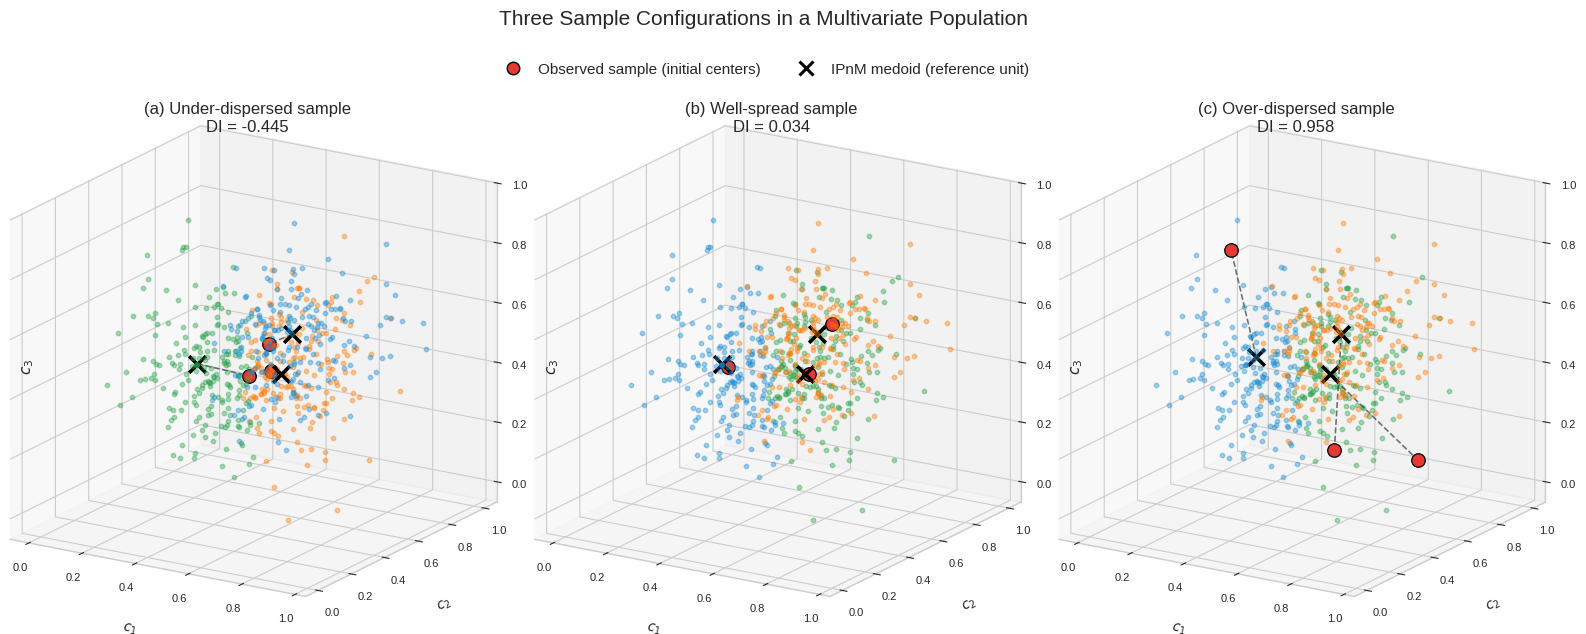

Saved figure: /home/bardia/projects/graphical-sampling/simulations/results/multivariate_3D_DI/synthetic_3D_three_DI_cases.png
Saved cluster details: /home/bardia/projects/graphical-sampling/simulations/results/multivariate_3D_DI/synthetic_3D_three_DI_cases_details.csv


In [4]:
fig = plt.figure(figsize=(18.5, 7.2))
axes = [fig.add_subplot(1, 3, j + 1, projection='3d') for j in range(3)]
cluster_colors = ['#168BD2', '#FF7A00', '#24A148']
panel_titles = ['(a) Under-dispersed sample', '(b) Well-spread sample', '(c) Over-dispersed sample']

for ax, (case_name, result), panel_title in zip(axes, cases, panel_titles):
    for k in range(n):
        mask = result['labels'] == k
        ax.scatter(*coords[mask].T, s=10, color=cluster_colors[k], alpha=0.38,
                   depthshade=False, rasterized=True)

    # Paper notation: observed samples are red bullets; IPnM medoids are black crosses.
    ax.scatter(*result['raw_sample'].T, marker='o', s=95, c='#E53935',
               edgecolors='black', linewidths=0.9, depthshade=False, zorder=6)
    ax.scatter(*result['medoids'].T, marker='x', s=145, c='black',
               linewidths=2.6, depthshade=False, zorder=7)

    for k in range(n):
        segment = np.vstack([result['medoids'][k], result['assigned_sample'][k]])
        ax.plot(*segment.T, color='0.25', ls='--', lw=1.15, alpha=0.75)

    ax.set_xlabel(r'$c_1$', labelpad=4)
    ax.set_ylabel(r'$c_2$', labelpad=4)
    ax.set_zlabel('')
    ax.text2D(0.015, 0.50, r'$c_3$', transform=ax.transAxes, rotation=90,
              va='center', ha='center', fontsize=16, fontweight='bold')
    ax.set_title(f'{panel_title}\nDI = {result["DI"]:.3f}', pad=11, fontsize=18, fontweight='bold')
    ax.set_proj_type('ortho')
    ax.set_box_aspect(np.ptp(coords, axis=0), zoom=1.30)
    ax.view_init(elev=18, azim=-58)
    ax.tick_params(labelsize=11, pad=1)
    ax.xaxis.label.set_size(15)
    ax.yaxis.label.set_size(15)

legend_items = [
    Line2D([0], [0], marker='o', color='none', markerfacecolor='#E53935',
           markeredgecolor='black', markersize=9, label='Observed sample (initial centers)'),
    Line2D([0], [0], marker='x', color='black', linestyle='none', markeredgewidth=2.2,
           markersize=10, label='IPnM medoid (reference unit)'),
]
fig.legend(handles=legend_items, loc='upper center', bbox_to_anchor=(0.5, 0.985),
           ncol=2, frameon=False, prop={'size': 18, 'weight': 'bold'},
           handletextpad=0.7, columnspacing=2.2)
fig.suptitle('Three Sample Configurations in a Multivariate Population', y=1.055, fontsize=24, fontweight='bold')
fig.subplots_adjust(left=0.015, right=0.995, bottom=0.025, top=0.73, wspace=0.01)

candidates = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
repo_root = next(p for p in candidates if (p / 'graphical_sampling').is_dir())
output_dir = repo_root / 'simulations/results/multivariate_3D_DI'
output_dir.mkdir(parents=True, exist_ok=True)
figure_file = output_dir / 'multivariate_3D_DI_three_cases_OT_large_text.png'
pdf_file = output_dir / 'multivariate_3D_DI_three_cases_OT_large_text.pdf'
table_file = output_dir / 'multivariate_3D_DI_three_cases_OT_large_text_details.csv'
fig.savefig(figure_file, dpi=320, bbox_inches='tight')
fig.savefig(pdf_file, bbox_inches='tight')
cluster_table.to_csv(table_file, index=False)
plt.show()
print('Saved figure:', figure_file)
print('Saved cluster details:', table_file)

## Reading the figure

Each sampled unit induces an initialization point, while the balanced clustering partitions the entire population into $n$ clusters with equal inclusion-probability mass. A medoid is an observed population unit representing each cluster. DI compares the original multivariate population density with the density obtained after translating each cluster so its medoid coincides with its optimally assigned sampled unit. Consequently, the calculation uses all three dimensions jointly rather than averaging three separate univariate indices.